# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Athlete Recovery Biometric Dataset](https://www.kaggle.com/datasets/sarveshchhetri/athlete-recovery-and-biometric-performance-dataset)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('athlete_recovery_synthetic.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,Athlete_ID,Day,Day_of_Week,Week,Age,Gender,Sport_Type,Training_Type,Training_Duration_Min,Training_Intensity,Sleep_Duration_Hours,Caffeine_Intake_mg,Stress_Level,Resting_Heart_Rate,HRV_ms,Mood_Score,Muscle_Soreness,Energy_Level,Recovery_Score
0,1000,1,1,1,28,Male,Team Sport,HIIT,46,7.9,7.7,270,High,59,75,4.3,4.8,5.9,51.1
1,1000,2,2,1,28,Male,Team Sport,Cardio,71,7.0,7.3,258,Low,55,79,5.9,4.0,5.8,63.7
2,1000,3,3,1,28,Male,Team Sport,HIIT,45,7.3,7.7,214,Medium,57,77,5.1,4.0,5.6,71.0
3,1000,4,4,1,28,Male,Team Sport,Cardio,86,7.5,7.9,228,High,61,71,3.0,6.2,2.7,37.2
4,1000,5,5,1,28,Male,Team Sport,HIIT,28,9.2,6.7,0,High,64,62,3.3,7.4,1.1,12.3


## last Five row

In [4]:
df.tail()

,Athlete_ID,Day,Day_of_Week,Week,Age,Gender,Sport_Type,Training_Type,Training_Duration_Min,Training_Intensity,Sleep_Duration_Hours,Caffeine_Intake_mg,Stress_Level,Resting_Heart_Rate,HRV_ms,Mood_Score,Muscle_Soreness,Energy_Level,Recovery_Score
8374,1299,24,3,4,28,Female,Strength,Strength,73,6.1,7.8,228,Medium,59,62,5.7,6.5,3.1,31.9
8375,1299,25,4,4,28,Female,Strength,Strength,56,5.2,6.8,0,Low,54,68,6.7,5.5,4.4,36.1
8376,1299,26,5,4,28,Female,Strength,Strength,50,4.9,7.3,167,Low,58,68,6.0,5.1,3.6,29.4
8377,1299,27,6,4,28,Female,Strength,Yoga,36,4.2,7.0,180,High,56,65,4.7,4.3,2.7,31.5
8378,1299,28,7,4,28,Female,Strength,Yoga,76,4.1,7.7,213,Low,51,86,4.5,2.1,6.2,80.3


## Shape of our dataset

In [5]:
df.shape

(8379, 19)

## List out all columns

In [6]:
df.columns

Index(['Athlete_ID', 'Day', 'Day_of_Week', 'Week', 'Age', 'Gender',
       'Sport_Type', 'Training_Type', 'Training_Duration_Min',
       'Training_Intensity', 'Sleep_Duration_Hours', 'Caffeine_Intake_mg',
       'Stress_Level', 'Resting_Heart_Rate', 'HRV_ms', 'Mood_Score',
       'Muscle_Soreness', 'Energy_Level', 'Recovery_Score'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

Athlete_ID                 int64
Day                        int64
Day_of_Week                int64
Week                       int64
Age                        int64
Gender                    object
Sport_Type                object
Training_Type             object
Training_Duration_Min      int64
Training_Intensity       float64
Sleep_Duration_Hours     float64
Caffeine_Intake_mg         int64
Stress_Level              object
Resting_Heart_Rate         int64
HRV_ms                     int64
Mood_Score               float64
Muscle_Soreness          float64
Energy_Level             float64
Recovery_Score           float64
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8379 entries, 0 to 8378
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Athlete_ID             8379 non-null   int64  
 1   Day                    8379 non-null   int64  
 2   Day_of_Week            8379 non-null   int64  
 3   Week                   8379 non-null   int64  
 4   Age                    8379 non-null   int64  
 5   Gender                 8379 non-null   object 
 6   Sport_Type             8379 non-null   object 
 7   Training_Type          8379 non-null   object 
 8   Training_Duration_Min  8379 non-null   int64  
 9   Training_Intensity     8378 non-null   float64
 10  Sleep_Duration_Hours   7775 non-null   float64
 11  Caffeine_Intake_mg     8379 non-null   int64  
 12  Stress_Level           8379 non-null   object 
 13  Resting_Heart_Rate     8379 non-null   int64  
 14  HRV_ms                 8379 non-null   int64  
 15  Mood

## Check Null Value

In [9]:
df.isnull().sum()

Athlete_ID                 0
Day                        0
Day_of_Week                0
Week                       0
Age                        0
Gender                     0
Sport_Type                 0
Training_Type              0
Training_Duration_Min      0
Training_Intensity         1
Sleep_Duration_Hours     604
Caffeine_Intake_mg         0
Stress_Level               0
Resting_Heart_Rate         0
HRV_ms                     0
Mood_Score                 0
Muscle_Soreness            0
Energy_Level               0
Recovery_Score             0
dtype: int64

## Training Intensity fill with Mean

In [10]:
df['Training_Intensity'] = df['Training_Intensity'].fillna(
    df['Training_Intensity'].mean()
)

## Drop Sleep Duration Hours Features

In [11]:
df.drop(columns=['Sleep_Duration_Hours'], inplace=True)

## Check Dupicate Value

In [12]:
df.duplicated().sum()

np.int64(0)

## Summary

In [13]:
df.describe()

,Athlete_ID,Day,Day_of_Week,Week,Age,Training_Duration_Min,Training_Intensity,Caffeine_Intake_mg,Resting_Heart_Rate,HRV_ms,Mood_Score,Muscle_Soreness,Energy_Level,Recovery_Score
count,8379.000000,8379.000000,8379.000000,8379.000000,8379.000000,8379.000000,8379.000000,8379.000000,8379.000000,8379.000000,8379.000000,8379.000000,8379.000000,8379.000000
mean,1149.458647,14.497076,3.998329,2.499821,25.860962,52.789712,6.211506,185.348132,57.202888,74.126507,5.177109,5.161953,3.273087,49.061356
std,86.631832,8.078044,2.000417,1.117941,4.531092,21.357704,2.368819,112.850208,5.790991,13.981632,1.210072,2.127583,1.679100,27.926347
min,1000.000000,1.000000,1.000000,1.000000,18.000000,10.000000,1.000000,0.000000,38.000000,22.000000,1.000000,1.000000,1.000000,0.000000
25%,1074.000000,8.000000,2.000000,2.000000,23.000000,36.000000,4.900000,126.000000,53.000000,64.000000,4.400000,3.600000,2.000000,27.800000
50%,1149.000000,14.000000,4.000000,2.000000,26.000000,56.000000,6.600000,212.000000,58.000000,74.000000,5.200000,5.200000,3.100000,48.900000
75%,1224.000000,21.000000,6.000000,3.000000,28.000000,69.000000,7.900000,268.000000,61.000000,84.000000,6.000000,6.700000,4.300000,69.900000
max,1299.000000,28.000000,7.000000,4.000000,41.000000,115.000000,10.000000,400.000000,81.000000,115.000000,9.500000,10.000000,10.000000,100.000000


# EDA

In [14]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

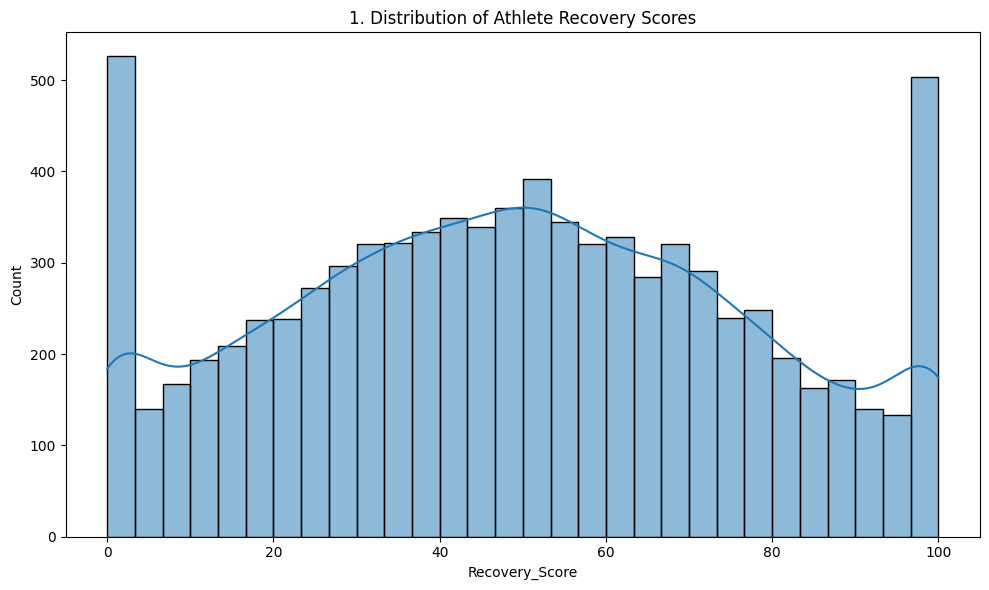

In [15]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['Recovery_Score'], kde=True, bins=30)
plt.title(f'{plot_no}. Distribution of Athlete Recovery Scores')
show_fig()
plot_no += 1

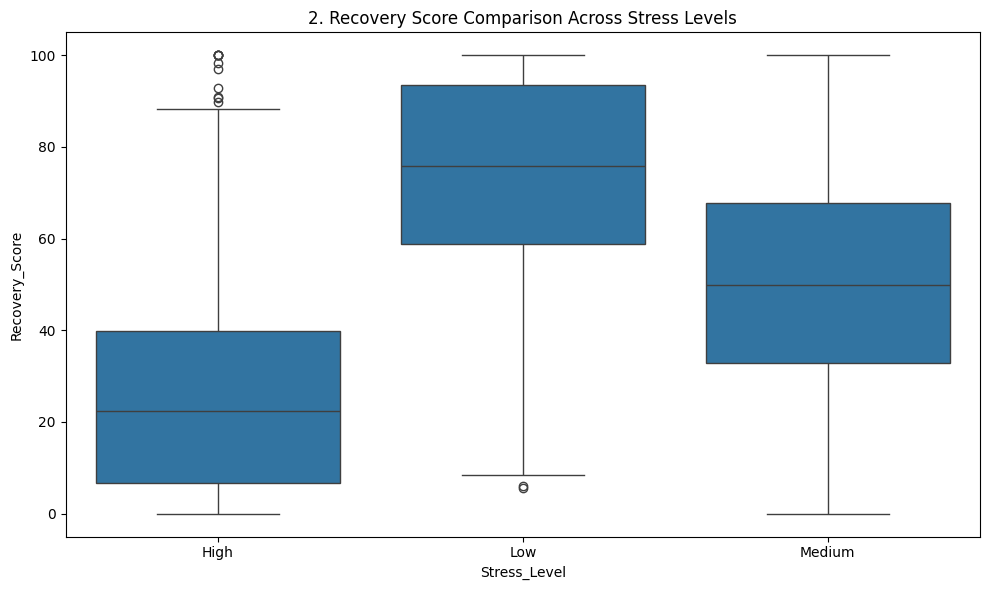

In [16]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='Stress_Level', y='Recovery_Score', data=df)
plt.title(f'{plot_no}. Recovery Score Comparison Across Stress Levels')
show_fig()
plot_no += 1

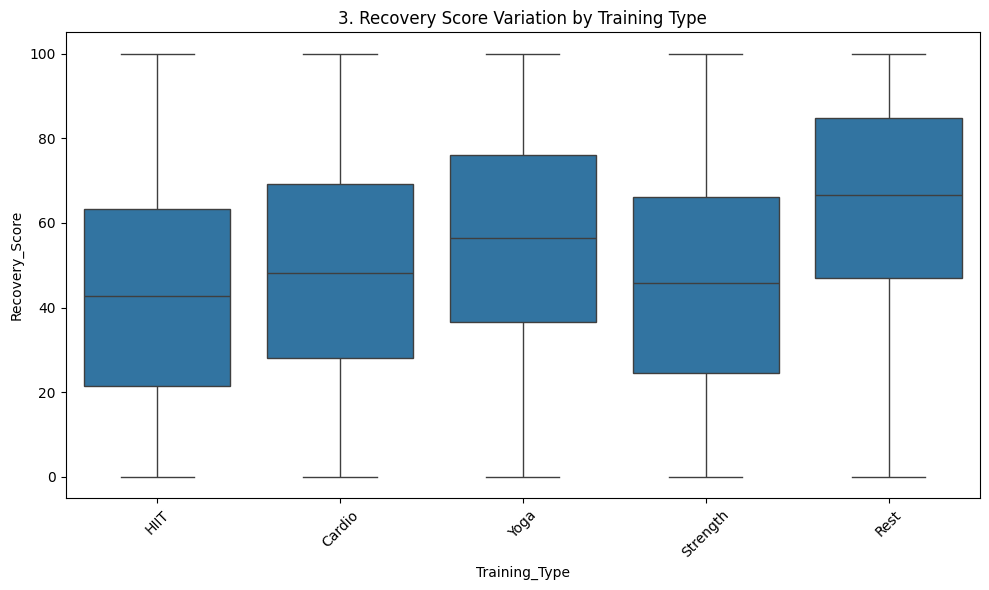

In [17]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='Training_Type', y='Recovery_Score', data=df)
plt.xticks(rotation=45)
plt.title(f'{plot_no}. Recovery Score Variation by Training Type')
show_fig()
plot_no += 1

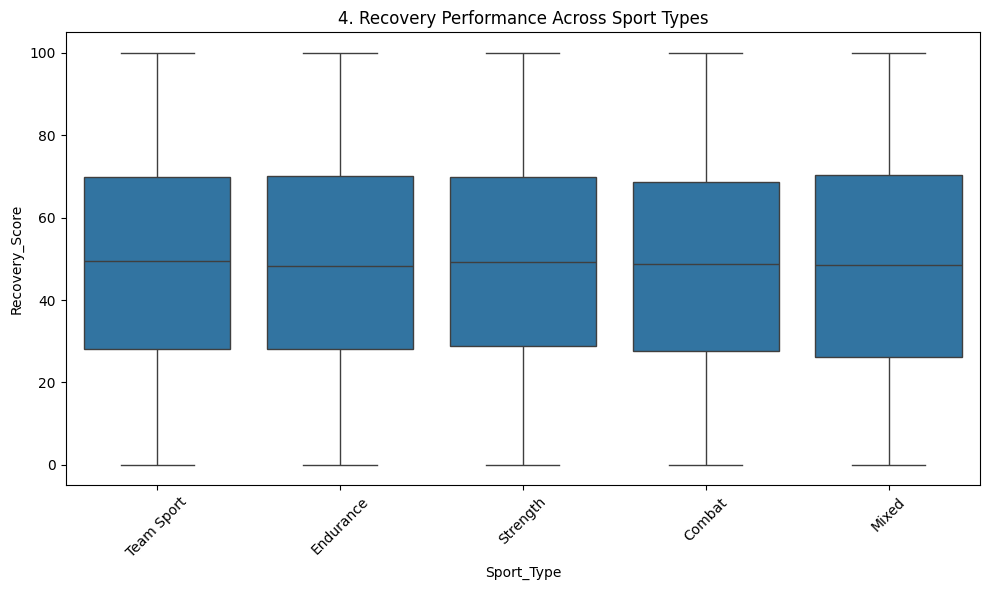

In [18]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='Sport_Type', y='Recovery_Score', data=df)
plt.xticks(rotation=45)
plt.title(f'{plot_no}. Recovery Performance Across Sport Types')
show_fig()
plot_no += 1

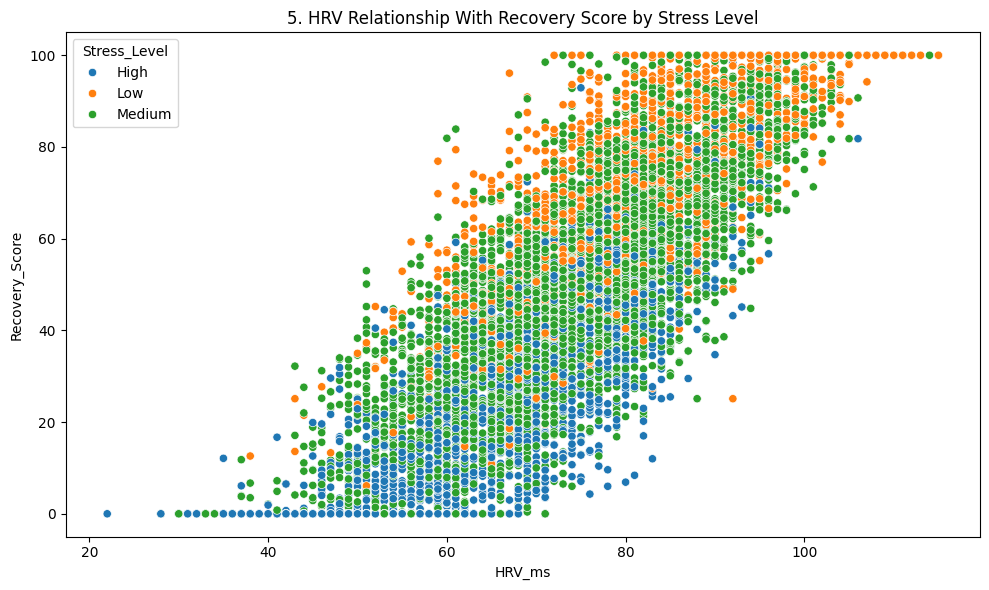

In [19]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='HRV_ms', y='Recovery_Score', hue='Stress_Level', data=df)
plt.title(f'{plot_no}. HRV Relationship With Recovery Score by Stress Level')
show_fig()
plot_no += 1

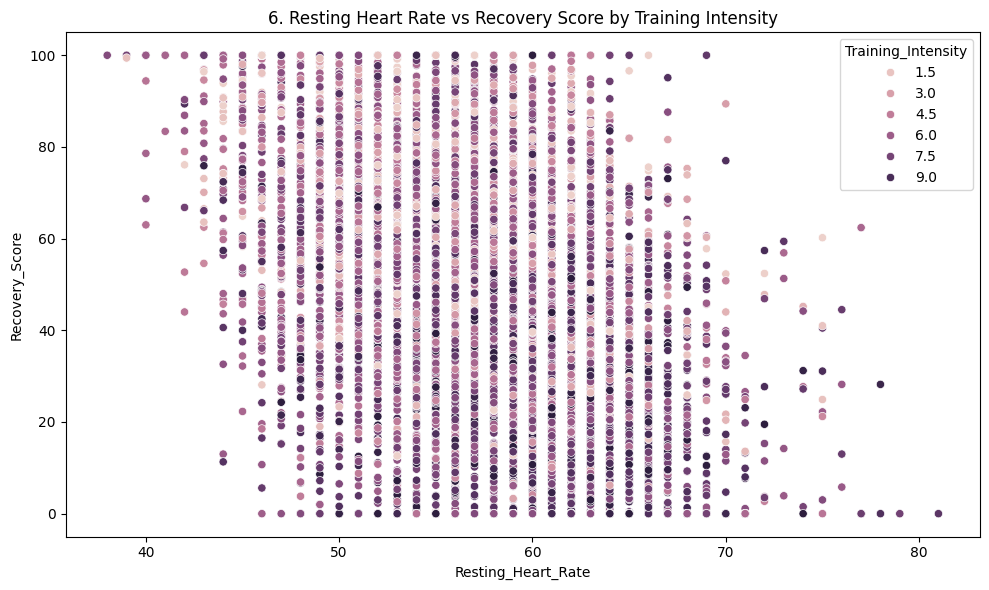

In [20]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='Resting_Heart_Rate', y='Recovery_Score', hue='Training_Intensity', data=df)
plt.title(f'{plot_no}. Resting Heart Rate vs Recovery Score by Training Intensity')
show_fig()
plot_no += 1

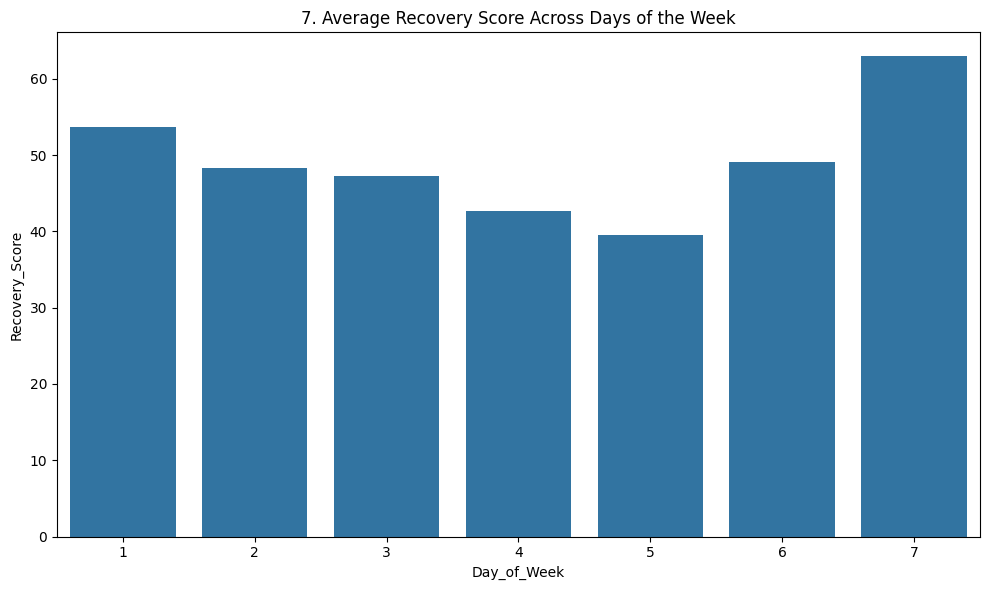

In [21]:
fig = plt.figure(figsize=(10,6))
sns.barplot(x='Day_of_Week', y='Recovery_Score', data=df, errorbar=None)
plt.title(f'{plot_no}. Average Recovery Score Across Days of the Week')
show_fig()
plot_no += 1

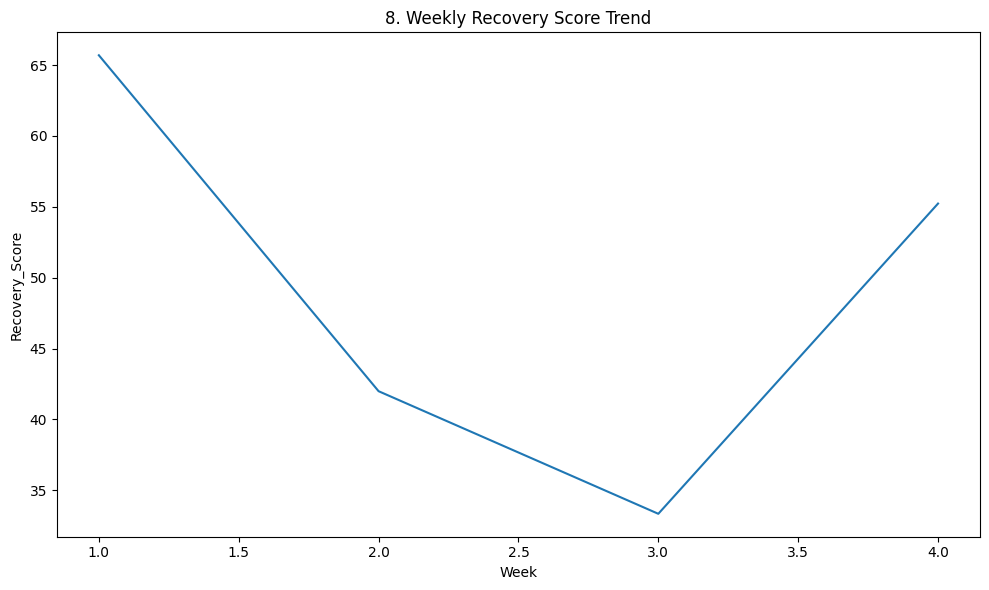

In [22]:
fig = plt.figure(figsize=(10,6))
sns.lineplot(x='Week', y='Recovery_Score', data=df, errorbar=None)
plt.title(f'{plot_no}. Weekly Recovery Score Trend')
show_fig()
plot_no += 1

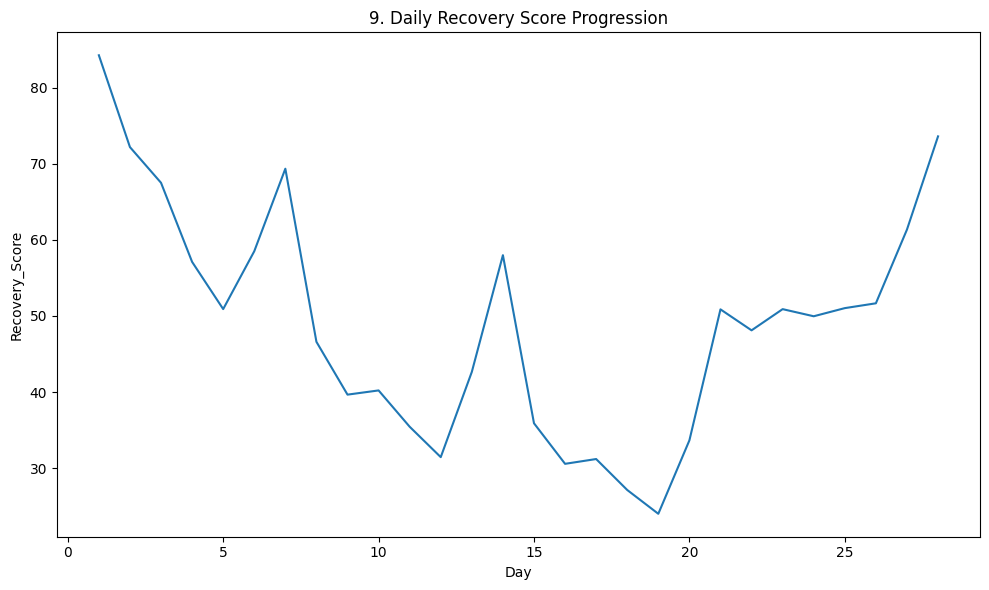

In [23]:
fig = plt.figure(figsize=(10,6))
sns.lineplot(x='Day', y='Recovery_Score', data=df, errorbar=None)
plt.title(f'{plot_no}. Daily Recovery Score Progression')
show_fig()
plot_no += 1

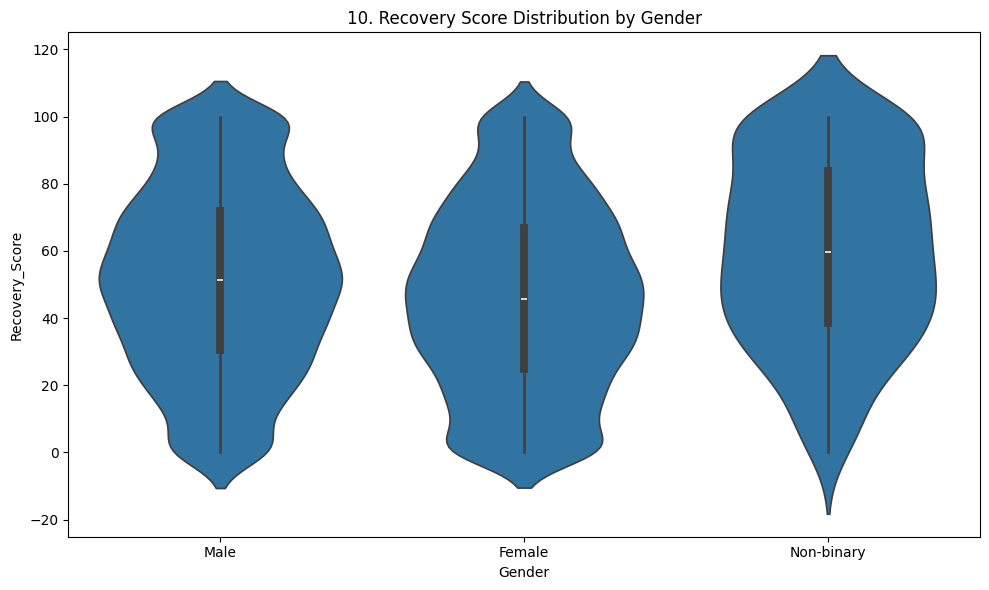

In [24]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(x='Gender', y='Recovery_Score', data=df)
plt.title(f'{plot_no}. Recovery Score Distribution by Gender')
show_fig()
plot_no += 1

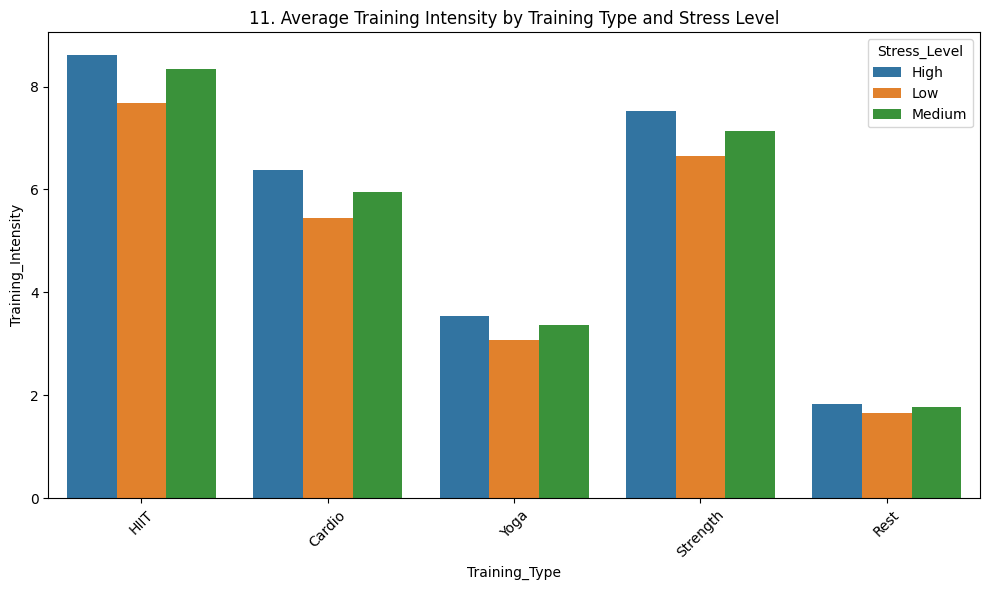

In [25]:
fig = plt.figure(figsize=(10,6))
sns.barplot(x='Training_Type', y='Training_Intensity', hue='Stress_Level', data=df, errorbar=None)
plt.xticks(rotation=45)
plt.title(f'{plot_no}. Average Training Intensity by Training Type and Stress Level')
show_fig()
plot_no += 1

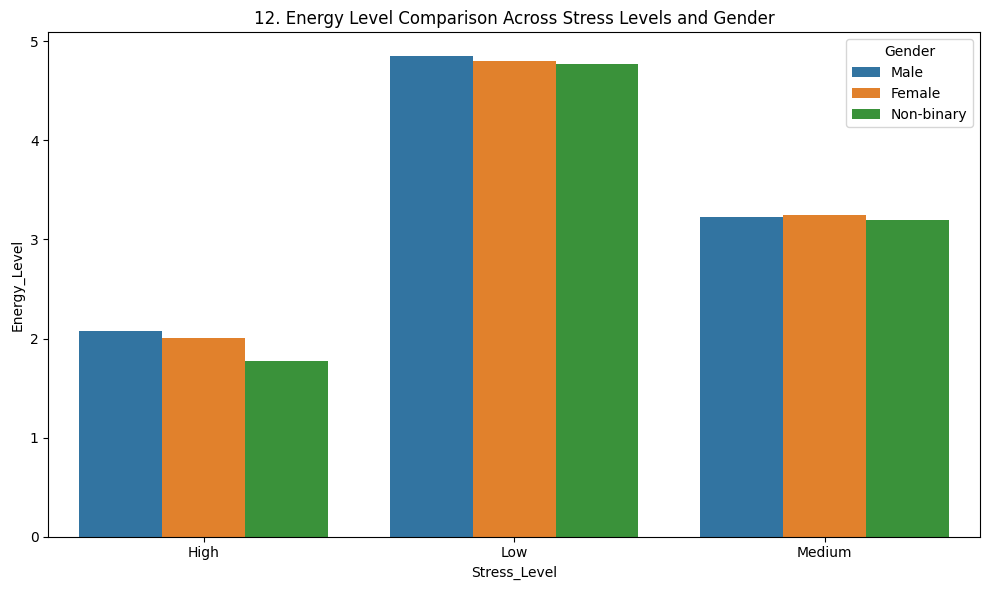

In [26]:
fig = plt.figure(figsize=(10,6))
sns.barplot(x='Stress_Level', y='Energy_Level', hue='Gender', data=df, errorbar=None)
plt.title(f'{plot_no}. Energy Level Comparison Across Stress Levels and Gender')
show_fig()
plot_no += 1

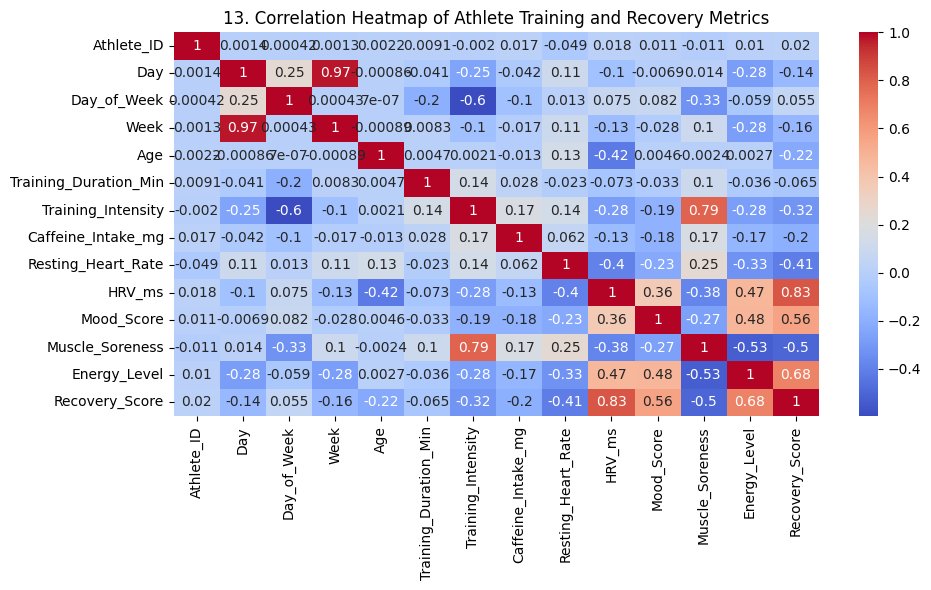

In [27]:
fig = plt.figure(figsize=(10,6))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title(f'{plot_no}. Correlation Heatmap of Athlete Training and Recovery Metrics')
show_fig()
plot_no += 1

# Model Training

## select features and target

In [28]:
X = df.drop(columns=['Recovery_Score'])
y = df['Recovery_Score']

## split numerical and categorical columns

In [29]:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

## create preprocessing steps

In [30]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

## create supervised regression model

In [31]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

## split data into training and testing parts

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## train the model

In [33]:
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## predict recovery score

In [34]:
y_pred = model.predict(X_test)

## calculate model accuracy scores

In [35]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Model Accuracy R2 Score:", r2)
print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)

Model Accuracy R2 Score: 0.8462394184619935
Mean Absolute Error: 8.610470125859585
Root Mean Squared Error: 10.966967033092777


## create actual vs predicted chart

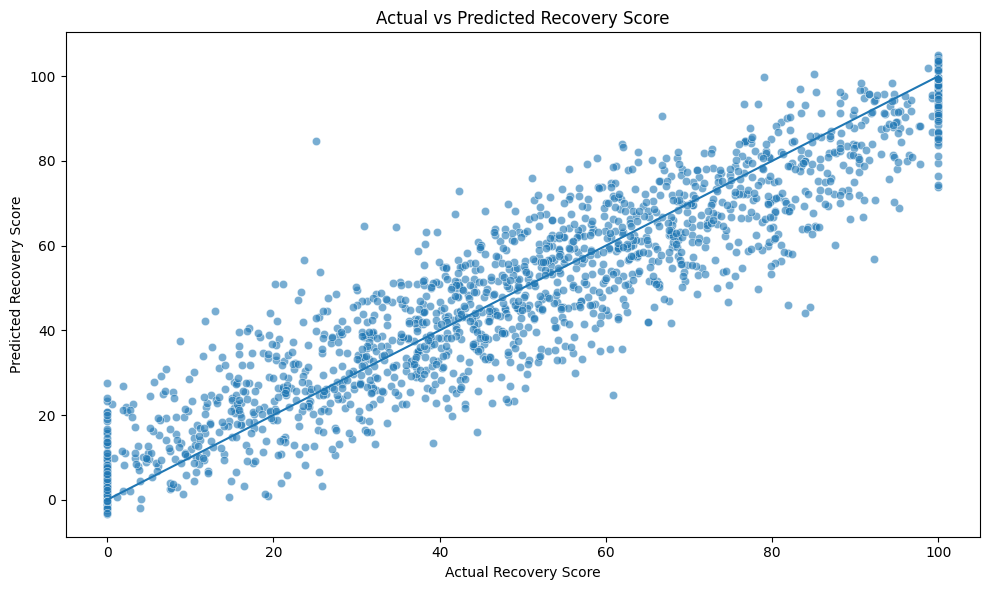

In [36]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.xlabel("Actual Recovery Score")
plt.ylabel("Predicted Recovery Score")
plt.title("Actual vs Predicted Recovery Score")
plt.tight_layout()
plt.show()